In [1]:
################################################
# Preparando los datos de la clasificación
################################################
import numpy as np
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt

# Scikit-learn buscará el conjunto de datos MNIST
print("Descargando MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

# Extraer datos y etiquetas
X, y = mnist.data, mnist.target

# Se divide el conjunto de datos
# 60.000 elementos para entrenamiento y 10.000 para prueba
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

print("Datos preparados.")

Descargando MNIST...
Datos preparados.


In [2]:
################################################
# 1. Entrenamiento de clasificadores binarios
################################################
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# Etiquetas binarias (5 vs el resto)
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

# Definimos los 4 clasificadores requeridos
clf_binarios = {
    "SGD": SGDClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Regística": LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42)
}

resultados_binarios = {}

print("Entrenando y evaluando en el test_set...")
for nombre, clf in clf_binarios.items():
    # Entrenamiento
    clf.fit(X_train, y_train_5)

    # Predicción en el conjunto de PRUEBA
    y_test_pred = clf.predict(X_test)

    # Obtenemos los scores para la curva ROC y AUC
    if hasattr(clf, "decision_function"):
        y_scores = clf.decision_function(X_test)
    else:
        y_scores = clf.predict_proba(X_test)[:, 1]

    # Midiendo el rendimiento del clasificador
    precision = precision_score(y_test_5, y_test_pred)
    recall = recall_score(y_test_5, y_test_pred)
    f1 = f1_score(y_test_5, y_test_pred)
    auc = roc_auc_score(y_test_5, y_scores)

    resultados_binarios[nombre] = {
        "precision": precision, "recall": recall, "f1": f1, "auc": auc, "scores": y_scores
    }
    print(f"{nombre} -> Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

Entrenando y evaluando en el test_set...
SGD -> Precision: 0.6619 | Recall: 0.8800 | F1: 0.7555 | AUC: 0.9666
KNN -> Precision: 0.9738 | Recall: 0.9574 | F1: 0.9655 | AUC: 0.9962


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Regística -> Precision: 0.9053 | Recall: 0.8363 | F1: 0.8695 | AUC: 0.9753
RandomForest -> Precision: 0.9936 | Recall: 0.8677 | F1: 0.9264 | AUC: 0.9992


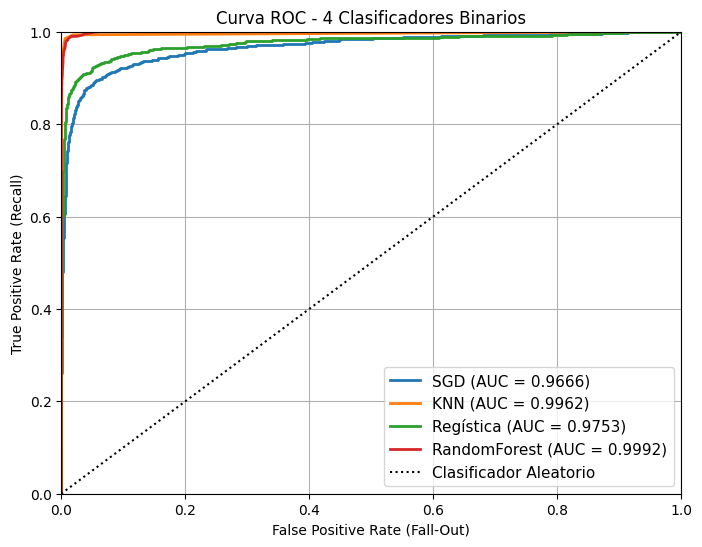

In [3]:
############################################
# Curva ROC - Clasificación Binaria
############################################
plt.figure(figsize=(8, 6))

# Dibujando la ROC curve para cada clasificador
for nombre, metricas in resultados_binarios.items():
    fpr, tpr, thresholds = roc_curve(y_test_5, metricas["scores"])
    plt.plot(fpr, tpr, linewidth=2, label=f"{nombre} (AUC = {metricas['auc']:.4f})")

plt.plot([0, 1], [0, 1], 'k:', label="Clasificador Aleatorio")
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Curva ROC - 4 Clasificadores Binarios')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=11)
plt.show()

In [5]:
################################################
# 2. Actividad clasificación multietiqueta
################################################
from sklearn.multioutput import MultiOutputClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

# Convertir a enteros para las operaciones matemáticas
y_train_int = y_train.astype(np.int8)
y_test_int = y_test.astype(np.int8)

# Condición 1: ¿Es par?
y_train_par = (y_train_int % 2 == 0)
y_test_par = (y_test_int % 2 == 0)

# Condición 2: ¿Está en el intervalo [5, 7]?
y_train_57 = (y_train_int >= 5) & (y_train_int <= 7)
y_test_57 = (y_test_int >= 5) & (y_test_int <= 7)

# Se crea la matriz multietiqueta
y_train_multi = np.c_[y_train_par, y_train_57]
y_test_multi = np.c_[y_test_par, y_test_57]

# Definimos los 4 clasificadores
clf_multi = {
    "KNN_Multi": KNeighborsClassifier(),
    "RandomForest_Multi": RandomForestClassifier(random_state=42),
    "SGD_Multi": MultiOutputClassifier(SGDClassifier(random_state=42)),
    "RegLog_Multi": MultiOutputClassifier(LogisticRegression(max_iter=1000, random_state=42))
}

resultados_multi = {}

print("Entrenando modelos multietiqueta...")
for nombre, clf in clf_multi.items():
    clf.fit(X_train, y_train_multi)
    y_test_pred = clf.predict(X_test)

    # Para multietiqueta, calculamos las métricas promediadas (macro)
    precision = precision_score(y_test_multi, y_test_pred, average="macro")
    recall = recall_score(y_test_multi, y_test_pred, average="macro")
    f1 = f1_score(y_test_multi, y_test_pred, average="macro")

    # Extracción de scores para AUC Multietiqueta (Lógica corregida)
    if hasattr(clf, "predict_proba"):
        probas = clf.predict_proba(X_test)
        if isinstance(probas, list):
            y_scores = np.c_[probas[0][:, 1], probas[1][:, 1]]
        else:
            y_scores = probas
    elif hasattr(clf, "estimators_"):
        # Extraemos manualmente el decision_function de cada modelo interno en MultiOutputClassifier
        score_par = clf.estimators_[0].decision_function(X_test)
        score_57 = clf.estimators_[1].decision_function(X_test)
        y_scores = np.c_[score_par, score_57]
    else:
        y_scores = clf.decision_function(X_test)

    # Calculamos el AUC promediado
    auc = roc_auc_score(y_test_multi, y_scores, average="macro")

    resultados_multi[nombre] = {
        "precision": precision, "recall": recall, "f1": f1, "auc": auc, "scores": y_scores
    }

    print(f"{nombre} -> Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

Entrenando modelos multietiqueta...
KNN_Multi -> Precision: 0.9821 | Recall: 0.9765 | F1: 0.9793 | AUC: 0.9950
RandomForest_Multi -> Precision: 0.9834 | Recall: 0.9585 | F1: 0.9706 | AUC: 0.9978
SGD_Multi -> Precision: 0.8477 | Recall: 0.7733 | F1: 0.8010 | AUC: 0.9242


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


RegLog_Multi -> Precision: 0.8675 | Recall: 0.8436 | F1: 0.8550 | AUC: 0.9488


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


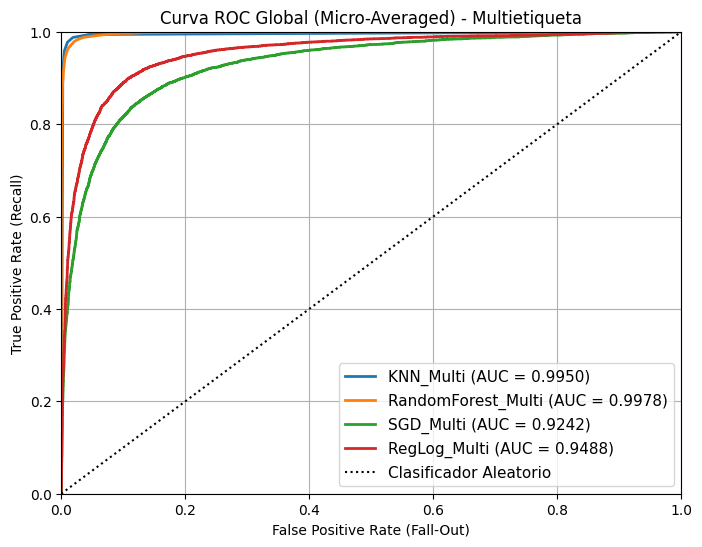

In [6]:
############################################
# Curva ROC - Clasificación Multietiqueta
############################################
plt.figure(figsize=(8, 6))

for nombre, metricas in resultados_multi.items():
    # Aplanamos las matrices (.ravel()) para calcular un ROC global (Micro-average)
    fpr, tpr, _ = roc_curve(y_test_multi.ravel(), metricas["scores"].ravel())

    plt.plot(fpr, tpr, linewidth=2, label=f"{nombre} (AUC = {metricas['auc']:.4f})")

plt.plot([0, 1], [0, 1], 'k:', label="Clasificador Aleatorio")
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Curva ROC Global (Micro-Averaged) - Multietiqueta')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=11)
plt.show()